<a href="https://colab.research.google.com/github/azhgh22/Monet_Style_Generator/blob/main/notebooks/eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Set Env**

In [2]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
user_name = userdata.get('GITHUB_USERNAME')
mail = userdata.get('GITHUB_MAIL')

!git config --global user.name "{user_name}"
!git config --global user.email "{mail}"
!git clone https://{token}@github.com/azhgh22/Monet_Style_Generator.git
!pip install -r ./Monet_Style_Generator/requirements.txt

MessageError: Error: credential propagation was unsuccessful

# **Imports**

In [24]:
import wandb
import sys
import os
import torch

# Add the root directory of the cloned repository to the Python path
sys.path.append('/content/Monet_Style_Generator')

import importlib
import utils.custom_dataset as custom_dataset_module
import utils.train_test_split as tts_module
import utils.dataset_assembly as ds_assembly_module
import utils.weight_initializer as weight_initializer
import eval.eval_utils as eval_module
import models.GAN.generator_models.resnet_gen_cut as res_gen_cut_module
import models.GAN.cut as cut_module
importlib.reload(custom_dataset_module)
importlib.reload(tts_module)
importlib.reload(ds_assembly_module)
importlib.reload(weight_initializer)
importlib.reload(eval_module)
importlib.reload(res_gen_cut_module)
importlib.reload(cut_module)
from utils.custom_dataset import CustomDataset
from utils.dataset_assembly import DatasetAssembly
from utils.train_test_split import TrainTestSplit
from utils.weight_initializer import WeightsInitializer
from pathlib import Path
from torch.utils.data import DataLoader
import torchvision.transforms as T
from eval.eval_utils import evaluate_mifid
from models.GAN.generator_models.resnet_gen_cut import ResnetGeneratorCut
from models.GAN.cut import Cut



# imort model

import models.GAN.generator_models.resnet_gen as res_gen
import models.GAN.discriminator_models.patchgan as patchgan
import models.GAN.cycle_gan as cycle_gan
import utils.train as train_module
import utils.checkpointer as checkpointer_module
importlib.reload(res_gen)
importlib.reload(patchgan)
importlib.reload(cycle_gan)
importlib.reload(train_module)
importlib.reload(checkpointer_module)
from models.GAN.generator_models.resnet_gen import ResnetGenerator
from models.GAN.discriminator_models.patchgan import PatchGANDiscriminator
from models.GAN.cycle_gan import CycleGAN
from utils.train import Train
from utils.checkpointer import Checkpointer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Read Data and Split data**

In [25]:
train, val, test = TrainTestSplit("/content/Monet_Style_Generator/data/photo_jpg/").split(0.7,0.15,0.15)

In [26]:
monet_pictures = list(Path("/content/Monet_Style_Generator/data/monet_jpg/").glob('*.jpg'))

In [27]:
# create datasets
transform = T.Compose([
    T.ToTensor(),
    T.ConvertImageDtype(torch.float)
])

train_part = CustomDataset(train,size=1000)
val_dataset = CustomDataset(val)
test_dataset = CustomDataset(test)

monet_dataset = CustomDataset(monet_pictures)

# train_dataset = DatasetAssembly(train_part, monet_dataset)
# train_dataset = CustomDataset(train_part)

In [28]:

import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision.utils import make_grid

def show_img(x: torch.Tensor):
  x = x.detach().cpu()
  x = x.permute(1, 2, 0)

  plt.imshow(x)
  plt.axis("off")
  plt.show()

# **Data Loaders**

In [29]:
train_loader = DataLoader(
    train_part,
    batch_size=1,
    shuffle=False,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
  )

monet_loader = DataLoader(
    monet_dataset,
    batch_size=1,
    shuffle=False,
)



# **Evaluation**

In [30]:
%%capture
monet_generator = ResnetGenerator()
monet_discriminator = PatchGANDiscriminator()

picture_generator = ResnetGenerator()
picture_discriminator = PatchGANDiscriminator()

cycle_gan_model = CycleGAN(monet_generator, picture_generator, monet_discriminator, picture_discriminator).to(device)


In [ ]:
%%capture
cut_monet_generator = ResnetGeneratorCut()
cut_monet_discriminator = PatchGANDiscriminator()

cut_model = Cut(cut_monet_generator, cut_monet_discriminator)
cut_model.to(device)

In [ ]:
checkpoint_dir = "/content/drive/MyDrive/checkpoints/cycle_gan_resnet_v1"

checkpointer = Checkpointer(checkpoint_dir,"cycle_gan",1,False)
train = Train(cycle_gan_model, 30, train_loader, checkpointer, device)
train.load_checkpoint()

Loaded latest checkpoint: /content/drive/MyDrive/checkpoints/cycle_gan_resnet_v1/cycle_gan_epoch_30.pt


In [ ]:
checkpoint_dir = "/content/drive/MyDrive/checkpoints/cut_resnet_v1"

checkpointer = Checkpointer(checkpoint_dir,"cut",1,False)
train = Train(cut_model, 30, train_loader, checkpointer, device)
train.load_checkpoint()

Loaded latest checkpoint: /content/drive/MyDrive/checkpoints/cut_resnet_v1/cut_epoch_30.pt


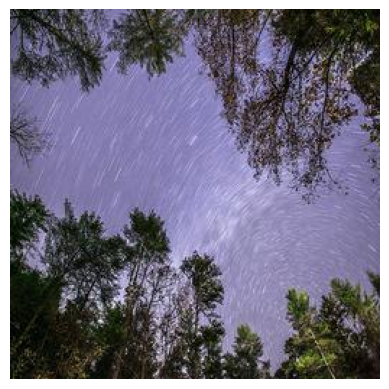

In [ ]:
show_img(val_dataset[3].to(device))

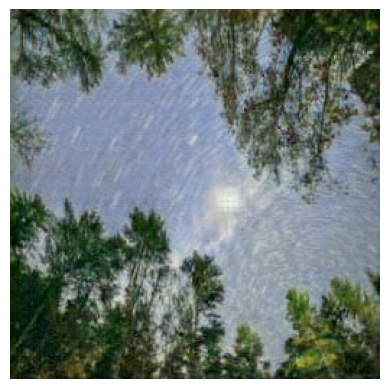

In [ ]:
gen = monet_generator.forward(val_dataset[3].to(device))
show_img(gen)

In [31]:
evaluate_mifid(monet_generator,train_loader,monet_loader,device,0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting features: 100%|██████████| 300/300 [00:05<00:00, 57.82it/s]


{'FID': 272.1587380964693, 'd_thr': 1.0, 'MiFID': 272.1587380964693}

# **Login Wandb**

In [32]:
!wandb login

wandb: Currently logged in as: azhgh22 (MLBeasts) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# **Eval Cycel_Gan**

In [33]:
%%capture
monet_generator = ResnetGenerator()
monet_discriminator = PatchGANDiscriminator()

picture_generator = ResnetGenerator()
picture_discriminator = PatchGANDiscriminator()

cycle_gan_model = CycleGAN(monet_generator, picture_generator, monet_discriminator, picture_discriminator).to(device)


checkpoint_dir = "/content/drive/MyDrive/checkpoints/cycle_gan_resnet_v1"

checkpointer = Checkpointer(checkpoint_dir,"cycle_gan",1,False)
train = Train(cycle_gan_model, 30, train_loader, checkpointer, device)

In [19]:
evaluation_train = evaluate_mifid(monet_generator,train_loader,monet_loader,device,0.5)
# evaluation_val = evaluate_mifid(monet_generator,val_loader,monet_loader,device,0.5)

Extracting features: 100%|██████████| 300/300 [00:04<00:00, 72.25it/s]


In [1]:
epochs = 30
CONFIG = {
    "epochs": 30,
    "batch_size": 1,
    "learning_rate": 0.0002,
    "optimizer_beta1": 0.5,
    "optimizer_beta2": 0.999,
    "img_pool_size" : 50,
    "lambda_cycle" : 10,
    "lambda_identity" : 5,
    "GAN loss" : "MSELoss",
    "cycle loss" : "L1Loss",
    "identity loss" : "L1Loss"
}

wandb.init(project="Monet_Generator", entity="azhgh22-free-university-of-tbilisi-", config=CONFIG)

for i in range(1,epochs+1):
  print("Epoch ",i)
  train.load_checkpoint(i)
  losses = train.epoch_losses
  epoch = i
  generators_loss = losses[-1]["G"]
  mone_disc_loss = losses[-1]["D_A"]
  picture_disc_loss = losses[-1]["D_B"]
  cycle_loss_pict = losses[-1]["cycle_A"]
  cycle_loss_monet = losses[-1]["cycle_B"]
  identity_loss_pict = losses[-1]["idt_A"]
  identity_loss_monet = losses[-1]["idt_B"]

  evaluation_train = evaluate_mifid(monet_generator,train_loader,monet_loader,device,0.5)
  evaluation_val = evaluate_mifid(monet_generator,val_loader,monet_loader,device,0.5)
  fid_train = evaluation_train["FID"]
  MiFID_train = evaluation_train["MiFID"]

  fid_val = evaluation_val["FID"]
  MiFID_val = evaluation_val["MiFID"]

  # Log Generator Loss separately
  wandb.log({
      "Generator Loss": generators_loss,
  })

  # Log Discriminator Losses separately
  wandb.log({
      "Monet Discriminator Loss": mone_disc_loss,
      "Picture Discriminator Loss": picture_disc_loss,
  })

  # Log Cycle Losses separately
  wandb.log({
      "epoch": epoch,
      "Cycle Loss Picture": cycle_loss_pict,
      "Cycle Loss Monet": cycle_loss_monet,
  })

  # Log Identity Losses separately
  wandb.log({
      "Identity Loss Picture": identity_loss_pict,
      "Identity Loss Monet": identity_loss_monet,
  })

  # Log FID/MiFID scores together
  wandb.log({
      "epoch": epoch,
      "FID_train": fid_train,
      "FID_val": fid_val,
  })

  # Log MiFID scores together
  wandb.log({
      "MiFID_train": MiFID_train,
      "MiFID_val": MiFID_val,
  })

  # Log generated images
  log_images = []
  for idx in range(5):
    # Ensure generator is in eval mode for consistent inference
    monet_generator.eval()

    train_img_orig = train_part[idx].to(device)
    val_img_orig = val_dataset[idx].to(device)

    # Generate images (add batch dimension for generator, then remove for logging)
    with torch.no_grad():
      train_gen_img = monet_generator(train_img_orig.unsqueeze(0)).squeeze(0).cpu()
      val_gen_img = monet_generator(val_img_orig.unsqueeze(0)).squeeze(0).cpu()

    log_images.append(wandb.Image(train_img_orig.cpu(), caption=f"Epoch {epoch} Train Original {idx}"))
    log_images.append(wandb.Image(train_gen_img, caption=f"Epoch {epoch} Train Generated {idx}"))
    log_images.append(wandb.Image(val_img_orig.cpu(), caption=f"Epoch {epoch} Val Original {idx}"))
    log_images.append(wandb.Image(val_gen_img, caption=f"Epoch {epoch} Val Generated {idx}"))

  wandb.log({"epoch": epoch, "Generated Samples": log_images})


  # Get state dictionaries
  monet_syle_gen_state = monet_generator.state_dict()
  picture_gen_state = picture_generator.state_dict()
  monet_disc_state = monet_discriminator.state_dict()
  picture_disc_state = picture_discriminator.state_dict()

  # Save and log monet_generator state dict as a model artifact
  torch.save(monet_syle_gen_state, f"monet_generator_epoch_{epoch}.pt")
  monet_gen_artifact = wandb.Artifact(f"monet_generator", type="model")
  monet_gen_artifact.add_file(f"monet_generator_epoch_{epoch}.pt")
  wandb.log_artifact(monet_gen_artifact, aliases=["latest", f"epoch_{epoch}"])
  os.remove(f"monet_generator_epoch_{epoch}.pt") # Clean up local file

  # Save and log picture_generator state dict as a model artifact
  torch.save(picture_gen_state, f"picture_generator_epoch_{epoch}.pt")
  picture_gen_artifact = wandb.Artifact(f"picture_generator", type="model")
  picture_gen_artifact.add_file(f"picture_generator_epoch_{epoch}.pt")
  wandb.log_artifact(picture_gen_artifact, aliases=["latest", f"epoch_{epoch}"])
  os.remove(f"picture_generator_epoch_{epoch}.pt") # Clean up local file

  # Save and log monet_discriminator state dict as a model artifact
  torch.save(monet_disc_state, f"monet_discriminator_epoch_{epoch}.pt")
  monet_disc_artifact = wandb.Artifact(f"monet_discriminator", type="model")
  monet_disc_artifact.add_file(f"monet_discriminator_epoch_{epoch}.pt")
  wandb.log_artifact(monet_disc_artifact, aliases=["latest", f"epoch_{epoch}"])
  os.remove(f"monet_discriminator_epoch_{epoch}.pt") # Clean up local file

  # Save and log picture_discriminator state dict as a model artifact
  torch.save(picture_disc_state, f"picture_discriminator_epoch_{epoch}.pt")
  picture_disc_artifact = wandb.Artifact(f"picture_discriminator", type="model")
  picture_disc_artifact.add_file(f"picture_discriminator_epoch_{epoch}.pt")
  wandb.log_artifact(picture_disc_artifact, aliases=["latest", f"epoch_{epoch}"])
  os.remove(f"picture_discriminator_epoch_{epoch}.pt") # Clean up local file

wandb.finish()


NameError: name 'wandb' is not defined